In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

data = pd.read_csv(
    "../data/cleaned/telco_customer_churn_cleaned.csv"
)

# Remove ID
data = data.drop(columns=["customerID"])

# Separate features and target
X = data.drop(columns=["Churn"])
y = data["Churn"].map({
    "No": 0,
    "Yes": 1
})

# Identify feature types
numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    include="str"
).columns.tolist()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [3]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [4]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [6]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter= 1000,
        random_state= 42
    ),

    "Decision tree": DecisionTreeClassifier(
        random_state= 42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators= 200,
        random_state= 42,
        n_jobs= -1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state= 42
    )
}

In [7]:
for name, model in models.items():
    model.fit(
        X_train_processed,
        y_train
    )
    print(f"\n {name} model has trained Succefssfully ")


 Logistic Regression model has trained Succefssfully 

 Decision tree model has trained Succefssfully 

 Random Forest model has trained Succefssfully 

 Gradient Boosting model has trained Succefssfully 


In [8]:
model_predictions = {}

for name, model in models.items():
    
    y_pred = model.predict(X_test_processed)
    y_probability = model.predict_proba(X_test_processed)[:, 1]
    
    model_predictions[name] = {
        "y_pred": y_pred,
        "y_probability": y_probability
    }
    
    print(f"{name} predictions generated successfully")

Logistic Regression predictions generated successfully
Decision tree predictions generated successfully
Random Forest predictions generated successfully
Gradient Boosting predictions generated successfully


In [9]:
model_result = {}

for name in models:

    y_pred = model_predictions[name]["y_pred"]
    y_probability = model_predictions[name]["y_probability"]

    results = pd.DataFrame(
        {
            "Actual": y_test.values,
            "predicted": y_pred,
            "Churn_Probability": y_probability
        }
    )

    model_result[name]= results

    print(f"\n\n {name} ")
    print(results.head())



 Logistic Regression 
   Actual  predicted  Churn_Probability
0       0          0           0.045920
1       0          1           0.683713
2       0          0           0.058940
3       0          0           0.401835
4       0          0           0.021424


 Decision tree 
   Actual  predicted  Churn_Probability
0       0          0                0.0
1       0          1                1.0
2       0          0                0.0
3       0          1                1.0
4       0          0                0.0


 Random Forest 
   Actual  predicted  Churn_Probability
0       0          0              0.000
1       0          1              0.725
2       0          0              0.070
3       0          0              0.305
4       0          0              0.015


 Gradient Boosting 
   Actual  predicted  Churn_Probability
0       0          0           0.023600
1       0          1           0.836548
2       0          0           0.065688
3       0          0           0.32234

In [10]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [11]:
evaluation_results = []

for name, model in models.items():

    # predictions
    y_pred = model.predict(X_test_processed)

    # churn Probablities
    y_probablities = model.predict_proba(X_test_processed)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_probability)

    # confusion Matrics
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")

    print("\nConfusion Matrix:")
    print(cm)

    print("\nAccuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)
    print("ROC-AUC  :", roc_auc)

    evaluation_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })


Logistic Regression

Confusion Matrix:
[[926 109]
 [165 209]]

Accuracy : 0.8055358410220014
Precision: 0.6572327044025157
Recall   : 0.5588235294117647
F1 Score : 0.6040462427745664
ROC-AUC  : 0.8432754656539823

Decision tree

Confusion Matrix:
[[832 203]
 [190 184]]

Accuracy : 0.7210787792760823
Precision: 0.4754521963824289
Recall   : 0.4919786096256685
F1 Score : 0.4835742444152431
ROC-AUC  : 0.8432754656539823

Random Forest

Confusion Matrix:
[[924 111]
 [194 180]]

Accuracy : 0.7835344215755855
Precision: 0.6185567010309279
Recall   : 0.48128342245989303
F1 Score : 0.5413533834586466
ROC-AUC  : 0.8432754656539823

Gradient Boosting

Confusion Matrix:
[[938  97]
 [181 193]]

Accuracy : 0.8026969481902059
Precision: 0.6655172413793103
Recall   : 0.516042780748663
F1 Score : 0.5813253012048193
ROC-AUC  : 0.8432754656539823


In [12]:
comparison_results = []

for name, model in models.items():

    y_pred = model.predict(X_test_processed)
    y_probability = model.predict_proba(X_test_processed)[:, 1]

    comparison_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_probability)
    })

comparison_df = pd.DataFrame(comparison_results)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.842135
1,Decision tree,0.721079,0.475452,0.491979,0.483574,0.647676
2,Random Forest,0.783534,0.618557,0.481283,0.541353,0.820602
3,Gradient Boosting,0.802697,0.665517,0.516043,0.581325,0.843275


In [13]:
comparison_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
3,Gradient Boosting,0.802697,0.665517,0.516043,0.581325,0.843275
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.842135
2,Random Forest,0.783534,0.618557,0.481283,0.541353,0.820602
1,Decision tree,0.721079,0.475452,0.491979,0.483574,0.647676


# Hyperparameter Tuning 

In [14]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

In [15]:
gb_model = GradientBoostingClassifier(
    random_state=42
)

In [16]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4]
}

In [17]:
grid_search = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [18]:
grid_search.fit(
    X_train_processed,
    y_train
)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [2, 3, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot

In [19]:
print(f"\n Best parameter >>> {grid_search.best_params_}")


 Best parameter >>> {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 200}


In [20]:
print(f"\n Best CV ROC-AUC >>> {grid_search.best_score_}")


 Best CV ROC-AUC >>> 0.8492422889946336


In [21]:
best_gb_model = grid_search.best_estimator_

In [22]:
tuned_y_pred = best_gb_model.predict(X_test_processed)

tuned_y_probability = best_gb_model.predict_proba(
    X_test_processed
)[:, 1]

In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, tuned_y_pred))
print("Precision:", precision_score(y_test, tuned_y_pred))
print("Recall   :", recall_score(y_test, tuned_y_pred))
print("F1 Score :", f1_score(y_test, tuned_y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, tuned_y_probability))

Accuracy : 0.7984386089425124
Precision: 0.65625
Recall   : 0.5053475935828877
F1 Score : 0.5709969788519638
ROC-AUC  : 0.8455075047146658


In [24]:
gb_model.fit(
    X_train_processed,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

In [25]:
gb_pred = gb_model.predict(X_test_processed)

gb_probability = gb_model.predict_proba(
    X_test_processed
)[:, 1]

In [26]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Before Tuning": [
        accuracy_score(y_test, gb_pred),
        precision_score(y_test, gb_pred),
        recall_score(y_test, gb_pred),
        f1_score(y_test, gb_pred),
        roc_auc_score(y_test, gb_probability)
    ],
    "After Tuning": [
        accuracy_score(y_test, tuned_y_pred),
        precision_score(y_test, tuned_y_pred),
        recall_score(y_test, tuned_y_pred),
        f1_score(y_test, tuned_y_pred),
        roc_auc_score(y_test, tuned_y_probability)
    ]
})

comparison

,Metric,Before Tuning,After Tuning
0,Accuracy,0.802697,0.798439
1,Precision,0.665517,0.656250
2,Recall,0.516043,0.505348
3,F1 Score,0.581325,0.570997
4,ROC-AUC,0.843275,0.845508


In [27]:
feature_importance = gb_model.feature_importances_

In [28]:
feature_names = preprocessor.get_feature_names_out()

In [29]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

In [30]:
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

In [31]:
importance_df.head(20)

,Feature,Importance
36,categorical__Contract_Month-to-month,0.379669
1,numeric__tenure,0.142279
16,categorical__InternetService_Fiber optic,0.086093
3,numeric__TotalCharges,0.085541
2,numeric__MonthlyCharges,0.080498
18,categorical__OnlineSecurity_No,0.067887
43,categorical__PaymentMethod_Electronic check,0.044171
27,categorical__TechSupport_No,0.037832
39,categorical__PaperlessBilling_No,0.013741
12,categorical__MultipleLines_No,0.011867


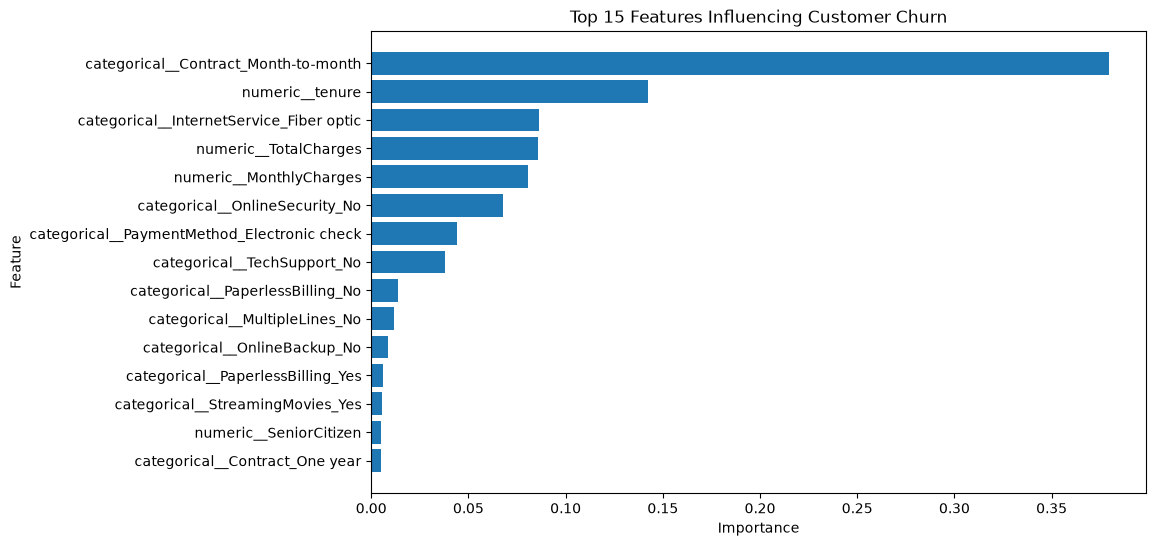

In [32]:
import matplotlib.pyplot as plt

top_features = importance_df.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features Influencing Customer Churn")

plt.gca().invert_yaxis()

plt.show()

In [33]:
importance_df.head(20)

,Feature,Importance
36,categorical__Contract_Month-to-month,0.379669
1,numeric__tenure,0.142279
16,categorical__InternetService_Fiber optic,0.086093
3,numeric__TotalCharges,0.085541
2,numeric__MonthlyCharges,0.080498
18,categorical__OnlineSecurity_No,0.067887
43,categorical__PaymentMethod_Electronic check,0.044171
27,categorical__TechSupport_No,0.037832
39,categorical__PaperlessBilling_No,0.013741
12,categorical__MultipleLines_No,0.011867


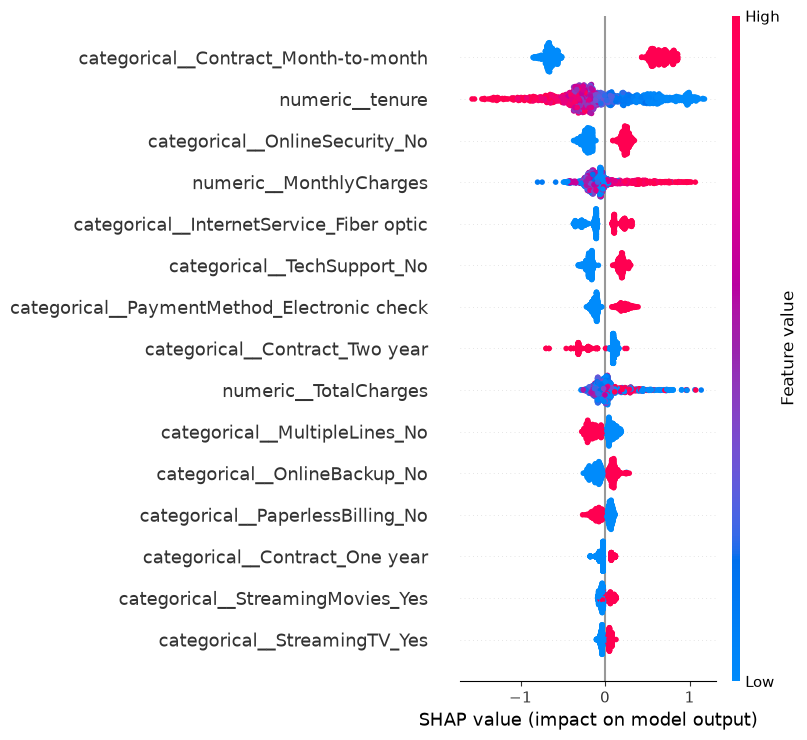

In [54]:
import shap

explainer = shap.TreeExplainer(gb_model)

shap_values = explainer.shap_values(
    X_test_processed,
    check_additivity=False
)

shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    max_display=15
)

## Model Explainability — SHAP Analysis

SHAP analysis was performed to understand how individual features influence
the Gradient Boosting model's churn predictions.

### Key Findings

- Month-to-month contract is the strongest predictor of churn risk.
- Lower customer tenure tends to push predictions toward churn.
- Customers without online security tend to have higher predicted churn risk.
- Higher monthly charges tend to push predictions toward churn.
- Fiber-optic internet service is associated with higher predicted churn risk.
- Customers without tech support tend to have higher predicted churn risk.
- Electronic-check payment method tends to push predictions toward churn.

These findings describe model behavior and should not be interpreted as
causal relationships.

In [55]:
final_model = gb_model